# 2.基于深度可分离卷积（Separable CNN）的图像分类模型

本章使用 PyTorch 构建基于 **深度可分离卷积（Depthwise Separable Convolution）** 的轻量级卷积神经网络，在保持分类精度的同时显著减少参数量和计算量，适合资源受限场景的图像分类任务。

**主要内容：**
- 深度可分离卷积原理介绍
- 轻量级网络架构设计与实现
- 模型训练、验证与性能评估
- 使用 TensorBoard 可视化训练过程

## 一、导入依赖库

In [1]:
import matplotlib as mpl          # 导入 matplotlib 绘图库基础模块，用于全局绘图参数配置
import matplotlib.pyplot as plt    # 导入 pyplot 子模块，提供类 MATLAB 的绘图接口（别名 plt）
%matplotlib inline                 
# Jupyter 魔术命令：将图表直接嵌入 Notebook 单元格输出中显示
import numpy as np                 # 导入 numpy，用于高效的数组/矩阵数值计算（别名 np）
import sklearn                     # 导入 scikit-learn 机器学习库，用于评估指标计算等
import pandas as pd                # 导入 pandas，用于数据处理与表格操作（别名 pd）
import os                          # 导入 os 模块，用于文件路径、目录创建等操作系统功能
import sys                         # 导入 sys 模块，用于访问 Python 解释器运行时信息（如版本号）
import time                        # 导入 time 模块，用于时间计时相关操作
from tqdm import tqdm         # 从 tqdm 导入自动选择环境的进度条类，用于显示训练进度

import torch                       # 导入 PyTorch 深度学习框架核心模块
import torch.nn as nn              # 导入 torch.nn，包含网络层、损失函数等构建模块（别名 nn）
import torch.nn.functional as F    # 导入函数式接口模块，提供激活函数等无参数操作（别名 F）

# 打印当前 Python 解释器版本信息，字段含义：major（主版本）、minor（次版本）、micro（修订版）
print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:  # 遍历各主要依赖库，逐一打印名称和版本号
    print(module.__name__, module.__version__)  # __name__ 为库名，__version__ 为版本字符串

# 检测运行环境：若 CUDA 可用则使用第 0 块 GPU，否则使用 CPU
# torch.device 参数说明：
#   "cuda:0" 表示编号为 0 的 GPU 设备
#   "cpu" 表示使用 CPU 计算
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 打印当前实际使用的计算设备名称

seed = 42  # 设定全局随机种子为 42，用于保证数据集划分的可复现性


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 二、数据准备

In [2]:
from torchvision import datasets              # 导入 torchvision.datasets，包含 FashionMNIST 等常用视觉数据集
from torchvision.transforms import ToTensor  # 导入 ToTensor 变换：将 PIL 图像转换为 [C,H,W] 的 FloatTensor，像素值归一化到 [0,1]
from torch.utils.data import random_split    # 导入 random_split，用于将 Dataset 随机划分为多个不重叠的子集

# 加载 FashionMNIST 训练集（共 60000 张 28×28 灰度图，10 个服装类别）
# datasets.FashionMNIST 参数说明：
#   root (str)       ：数据集下载和缓存的根目录
#   train (bool)     ：True 表示加载训练集，False 表示加载测试集
#   download (bool)  ：若本地不存在则自动从网络下载数据
#   transform        ：对每张图像应用的预处理变换对象
train_ds = datasets.FashionMNIST(
    root="data",         # 数据存储根目录，会在此目录下创建 FashionMNIST 子文件夹
    train=True,          # 加载训练集（60000 张图片）
    download=True,       # 若本地不存在则自动从网络下载
    transform=ToTensor() # 将 PIL 图像转换为 shape=(1,28,28) 的 FloatTensor，值域 [0,1]
)

# 加载 FashionMNIST 测试集（共 10000 张图片），用于最终模型评估
test_ds = datasets.FashionMNIST(
    root="data",         # 与训练集使用相同的根目录
    train=False,         # 加载测试集（10000 张图片）
    download=True,       # 若本地不存在则自动下载
    transform=ToTensor() # 同样将图像转换为 FloatTensor
)

# torchvision 数据集里没有提供训练集和验证集的划分
# 这里用 random_split 按照 11 : 1 的比例来划分数据集
# random_split 参数说明：
#   dataset           ：待划分的 Dataset 对象
#   lengths (list[int])：各子集的样本数量，[55000, 5000] 表示训练 55000 张、验证 5000 张
#   generator         ：随机数生成器，manual_seed(seed) 固定种子，保证每次划分结果一致
# 返回值：两个 Subset 对象，分别对应训练集和验证集
train_ds, val_ds = random_split(train_ds, [55000, 5000], torch.Generator().manual_seed(seed))

In [3]:
from torchvision.transforms import Normalize  # 导入 Normalize 变换：对图像各通道执行标准化，公式为 (x - mean) / std

# 定义函数，利用方差公式 Var(X) = E[X²] - E[X]² 对整个数据集精确计算各通道均值与标准差
# 原理说明：
#   不能用"逐张求 std 再取平均"的方式，因为 E[std_i] ≠ std(全体像素)
#   正确做法是分别累加 E[X] 和 E[X²]，再由公式推导出总体标准差
#   前提：数据集中每张图像的空间尺寸 H×W 相同（各像素权重相等）
# 参数说明：
#   ds (Dataset)：包含 (image_tensor, label) 元组的 PyTorch Dataset 对象
# 返回值：
#   mean    (Tensor)：各通道的总体均值，shape 为 (C,)，C 为通道数
#   std     (Tensor)：各通道的总体标准差，shape 为 (C,)
def cal_mean_std(ds):
    mean = 0.     # 累加每张图各通道像素均值 E[X]，shape=(C,)
    mean_sq = 0.  # 累加每张图各通道像素平方均值 E[X²]，shape=(C,)
    for img, _ in ds:                        # 遍历数据集，img shape=(C,H,W)，标签用 _ 忽略
        mean    += img.mean(dim=(1, 2))      # 对空间维度 (H,W) 求均值，累加每通道的 E[X]，shape=(C,)
        mean_sq += (img ** 2).mean(dim=(1, 2))  # 先对像素逐元素平方，再对 (H,W) 求均值，累加 E[X²]，shape=(C,)
    mean    /= len(ds)   # 对 N 张图取平均，得到数据集级别的 E[X]（图像尺寸相同故权重相等）
    mean_sq /= len(ds)   # 对 N 张图取平均，得到数据集级别的 E[X²]
    # 利用方差公式：Var(X) = E[X²] - E[X]²，开根号得标准差
    std = (mean_sq - mean ** 2).sqrt()  # shape=(C,)，即总体标准差
    return mean, std  # 返回各通道总体均值与总体标准差


data_mean,data_std=cal_mean_std(train_ds)
data_mean,data_std=data_mean.item(),data_std.item()
print(f"训练集上图像的单通道均值是{data_mean}，单通道标准差是{data_std}")

# 构建标准化变换序列，使用预先计算好的均值和标准差
# nn.Sequential：将多个变换/层串联成顺序管道
# Normalize 参数说明：
#   mean (list[float])：各通道均值，FashionMNIST 为单通道，均值取 0.2856
#   std  (list[float])：各通道标准差，取 0.3202
# 变换效果：将像素值从 [0,1] 范围标准化为均值 0、标准差 1 的分布
transforms = nn.Sequential(
    Normalize([data_mean], [data_std])  # 对 FashionMNIST 灰度图像执行单通道标准化
)

训练集上图像的单通道均值是0.28556734323501587，单通道标准差是0.3527269959449768


In [4]:
from torch.utils.data.dataloader import DataLoader  # 导入 DataLoader，用于批量加载数据，支持多进程读取和随机打乱

batch_size = 32  # 每个 mini-batch 的样本数量，设为 32（常用值，兼顾训练速度与梯度估计质量）

# 从数据集到dataloader
# DataLoader 参数说明：
#   dataset     (Dataset) ：数据来源的 Dataset 对象
#   batch_size  (int)     ：每批次加载的样本数
#   shuffle     (bool)    ：True 表示每个 epoch 开始时随机打乱数据顺序，训练集建议开启
#   num_workers (int)     ：用于数据预加载的子进程数，增大可加速 I/O，但会增加内存占用

# 训练集 DataLoader：启用随机打乱（shuffle=True），防止模型记忆样本顺序，提升泛化能力
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4)
# 验证集 DataLoader：不打乱（shuffle=False），保证每次验证结果稳定可复现
val_loader = DataLoader(val_ds, batch_size=batch_size*4, shuffle=False, num_workers=4)
# 测试集 DataLoader：不打乱，用于最终模型性能评估
test_loader = DataLoader(test_ds, batch_size=batch_size*4, shuffle=False, num_workers=4)

## 三、定义模型（深度可分离卷积）

本节使用**深度可分离卷积（Depthwise Separable Convolution）** 替代标准卷积，以大幅减少参数量和计算量。

PyTorch 没有内置该层，需手动实现。

### 3.1 定义深度可分离卷积层（DepthWiseConv2d）

In [5]:
# 定义深度可分离卷积层（Depthwise Separable Convolution）
# PyTorch 未内置该层（TensorFlow/Keras 中有 SeparableConv2D），需手动实现
# 深度可分离卷积由两步组成：
#   1. 深度卷积（Depthwise Conv）：每个输入通道独立进行空间卷积，不跨通道混合信息
#   2. 逐点卷积（Pointwise Conv）：用 1×1 卷积将各通道信息融合，完成通道数变换
# 与标准卷积相比，深度可分离卷积可大幅减少参数量和计算量
class DepthWiseConv2d(nn.Module):
    # 初始化方法
    # 参数说明：
    #   in_channels  (int)      ：输入特征图的通道数
    #   out_channels (int)      ：输出特征图的通道数（由逐点卷积决定）
    #   kernel_size  (int/tuple)：深度卷积核的空间尺寸（如 3 表示 3×3）
    #   stride       (int)      ：深度卷积的步长，默认为 1
    #   padding      (int/str)  ：深度卷积的填充量，默认为 0（可传 "same" 保持尺寸不变）
    #   bias         (bool)     ：逐点卷积是否使用偏置项，默认为 True
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        super().__init__()  # 调用父类 nn.Module 的初始化方法
        # 深度卷积层：groups=in_channels 使每个输入通道拥有独立的卷积核，实现逐通道空间卷积
        # bias=False：深度卷积不使用偏置（偏置由后续逐点卷积统一处理）
        # 输出 shape：(batch, in_channels, H', W')，通道数不变
        self.depthwise_conv = nn.Conv2d(
            in_channels, in_channels, kernel_size, stride, padding,
            groups=in_channels,  # groups=in_channels 表示每个通道使用独立卷积核（深度卷积的关键参数）
            bias=False           # 深度卷积不添加偏置项
        )
        # 逐点卷积层：1×1 卷积核，步长 1，无填充，负责跨通道信息融合和通道数变换
        # 输出 shape：(batch, out_channels, H', W')
        self.pointwise_conv = nn.Conv2d(in_channels, out_channels, 1, 1, 0, bias=bias)

    # 前向传播方法
    # 参数说明：
    #   x (Tensor)：输入特征图，shape 为 (batch_size, in_channels, H, W)
    # 返回值：
    #   Tensor，shape 为 (batch_size, out_channels, H', W')
    def forward(self, x):
        x = self.depthwise_conv(x)   # 步骤1：深度卷积，对每个通道独立进行空间卷积，通道数不变
        x = self.pointwise_conv(x)   # 步骤2：逐点卷积，用 1×1 卷积融合各通道信息，改变通道数
        return x                     # 返回深度可分离卷积后的特征图

### 3.2 定义 CNN 模型（使用深度可分离卷积）

In [6]:
# 定义使用深度可分离卷积的 CNN 模型（含输入标准化、BN 归一化、Kaiming 初始化、AlphaDropout）
# 网络结构：标准化变换 → 标准卷积(conv1) → 深度可分离卷积(conv2~conv6，每层后接BN) → 全连接层(BN+AlphaDropout) → 分类输出
class CNN(nn.Module):
    # 初始化方法，定义网络所有层的结构
    # 参数说明：
    #   transforms (nn.Module)：输入预处理模块（标准化变换），在前向传播第一步执行
    #   activation (str)      ：激活函数类型，'relu' 使用 ReLU，其他值使用 SELU；默认 'relu'
    def __init__(self, activation="relu"):
        super().__init__()  # 调用父类 nn.Module 的初始化方法，完成模块注册
        # 保存标准化变换模块，forward 中第一步调用以对输入进行均值/方差归一化
        self.transforms = transforms
        # 根据传入参数选择激活函数：F.relu（修正线性单元）或 F.selu（自归一化线性单元）
        self.activation = F.relu if activation == "relu" else F.selu

        # ── 卷积块定义 ────────────────────────────────────────────────
        # 第一层：标准二维卷积，输入通道 1（灰度图），输出通道 32，3×3 卷积核
        # padding="same" 表示输出与输入的空间尺寸相同（28×28 → 28×28）
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding="same")

        # 第二层：深度可分离卷积，通道数 32→32，same 填充保持尺寸
        self.conv2 = DepthWiseConv2d(in_channels=32, out_channels=32, kernel_size=3, padding="same")
        # conv2 之后的二维批归一化（BN2d）：对 32 个特征通道做归一化，稳定梯度、加速收敛
        # 参数 num_features=32：与 conv2 输出通道数一致；γ(weight) 初始化为 1，β(bias) 初始化为 0
        self.bn2 = nn.BatchNorm2d(32)

        # 最大池化层：2×2 窗口、步长 2，将特征图空间尺寸减半（三组卷积块共复用此层）
        self.pool = nn.MaxPool2d(2, 2)

        # 第三层：深度可分离卷积，通道数 32→64（扩大感受野，增加特征多样性）
        self.conv3 = DepthWiseConv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same")
        # conv3 之后的 BN2d，对 64 个通道进行归一化
        self.bn3 = nn.BatchNorm2d(64)
        # 第四层：深度可分离卷积，通道数 64→64
        self.conv4 = DepthWiseConv2d(in_channels=64, out_channels=64, kernel_size=3, padding="same")
        # conv4 之后的 BN2d，对 64 个通道进行归一化
        self.bn4 = nn.BatchNorm2d(64)

        # 第五层：深度可分离卷积，通道数 64→128
        self.conv5 = DepthWiseConv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same")
        # conv5 之后的 BN2d，对 128 个通道进行归一化
        self.bn5 = nn.BatchNorm2d(128)
        # 第六层：深度可分离卷积，通道数 128→128
        self.conv6 = DepthWiseConv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same")
        # conv6 之后的 BN2d，对 128 个通道进行归一化
        self.bn6 = nn.BatchNorm2d(128)

        # ── 全连接块定义 ──────────────────────────────────────────────
        # 展平层：将多维特征图 (batch, C, H, W) 展平为 (batch, C*H*W)，送入全连接层
        self.flatten = nn.Flatten()
        # 全连接层1：输入维度为 128×3×3=1152（经过 3 次池化后特征图变为 3×3）
        self.fc1 = nn.Linear(128 * 3 * 3, 128)   # 1152 → 128
        # fc1 之后的一维批归一化（BN1d），对 128 维特征向量做归一化，减少内部协变量偏移
        # num_features=128：与 fc1 输出维度一致
        self.bn_fc1 = nn.BatchNorm1d(128)
        # AlphaDropout：训练时以概率 p=0.5 随机将神经元置零并保持均值/方差不变
        # 与 ReLU/SELU 均兼容；推理阶段（model.eval()）自动停用，不影响预测
        self.dropout = nn.AlphaDropout(p=0.5)
        # 全连接层2（分类头）：输入 128，输出 10（FashionMNIST 共 10 个服装类别）
        self.fc2 = nn.Linear(128, 10)

        self.init_weights()  # 调用权重初始化方法，统一初始化各层权重

    def init_weights(self):
        """使用 Kaiming（He）正态分布初始化卷积层与全连接层的权重（适配 ReLU 激活函数）"""
        for m in self.modules():  # 遍历模型中所有子模块（包括嵌套子模块）
            if isinstance(m, (nn.Linear, nn.Conv2d)):  # 仅对 Linear 和 Conv2d 层执行 Kaiming 初始化
                # Kaiming 正态分布初始化（He 初始化）参数说明：
                #   mode='fan_out'      ：以输出扇出数（输出通道 × 卷积核大小）为基准计算缩放方差
                #                        使反向传播梯度在各层方差保持稳定，适合深层网络
                #   nonlinearity='relu' ：针对 ReLU 激活乘以修正因子 sqrt(2)，
                #                        补偿 ReLU 将负半轴截为 0 导致的方差缩减
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:      # 若该层含偏置项（bias）
                    nn.init.zeros_(m.bias)  # 将偏置初始化为全零，避免引入额外的初始偏移量
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):  # BN 层使用标准初始化
                nn.init.ones_(m.weight)     # 缩放参数 γ 初始化为 1，保持初始阶段归一化后输出不被缩放
                nn.init.zeros_(m.bias)      # 偏移参数 β 初始化为 0，保持初始阶段归一化后均值为 0

    # 前向传播方法，定义数据流经网络的完整计算过程
    # 参数说明：
    #   x (Tensor)：输入批次图像，shape 为 (batch_size, 1, 28, 28)，像素值范围 [0, 1]
    # 返回值：
    #   logits (Tensor)：各类别的原始分数（未经 softmax），shape 为 (batch_size, 10)
    def forward(self, x):
        act = self.activation                  # 引用激活函数，简化后续代码书写
        x = self.transforms(x)                 # 步骤0：输入标准化（均值/方差归一化），shape 不变 (batch_size, 1, 28, 28)
        # 第一组：conv1(标准卷积) → act → conv2(深度可分离) → BN2 → act → pool，28×28→14×14
        # 数据流：conv1 → ReLU → conv2 → bn2 → ReLU → MaxPool
        x = self.pool(act(self.bn2(self.conv2(act(self.conv1(x))))))    # (batch_size, 32, 14, 14)
        # 第二组：conv3 → BN3 → act → conv4 → BN4 → act → pool，14×14→7×7
        # 数据流：conv3 → bn3 → ReLU → conv4 → bn4 → ReLU → MaxPool
        x = self.pool(act(self.bn4(self.conv4(act(self.bn3(self.conv3(x)))))))  # (batch_size, 64, 7, 7)
        # 第三组：conv5 → BN5 → act → conv6 → BN6 → act → pool，7×7→3×3
        # 数据流：conv5 → bn5 → ReLU → conv6 → bn6 → ReLU → MaxPool
        x = self.pool(act(self.bn6(self.conv6(act(self.bn5(self.conv5(x)))))))  # (batch_size, 128, 3, 3)
        x = self.flatten(x)                              # 展平：(batch_size, 1152)
        x = self.dropout(self.bn_fc1(act(self.fc1(x))))  # fc1 → act → BN1d → AlphaDropout：(batch_size, 128)
        x = self.fc2(x)                                  # 分类输出（无激活）：(batch_size, 10)
        return x                                         # 返回未归一化的类别 logit

# 实例化 CNN（传入预定义的标准化变换 transforms）并打印各层参数名称及参数元素总数
for idx, (key, value) in enumerate(CNN().named_parameters()):
    # key   (str)   ：参数名称，如 'conv1.weight'、'bn2.weight'、'bn_fc1.bias'
    # value (Tensor)：对应的参数张量，np.prod(value.shape) 计算所有维度乘积即参数元素个数
    print(f"{key}\tparamerters num: {np.prod(value.shape)}")


conv1.weight	paramerters num: 288
conv1.bias	paramerters num: 32
conv2.depthwise_conv.weight	paramerters num: 288
conv2.pointwise_conv.weight	paramerters num: 1024
conv2.pointwise_conv.bias	paramerters num: 32
bn2.weight	paramerters num: 32
bn2.bias	paramerters num: 32
conv3.depthwise_conv.weight	paramerters num: 288
conv3.pointwise_conv.weight	paramerters num: 2048
conv3.pointwise_conv.bias	paramerters num: 64
bn3.weight	paramerters num: 64
bn3.bias	paramerters num: 64
conv4.depthwise_conv.weight	paramerters num: 576
conv4.pointwise_conv.weight	paramerters num: 4096
conv4.pointwise_conv.bias	paramerters num: 64
bn4.weight	paramerters num: 64
bn4.bias	paramerters num: 64
conv5.depthwise_conv.weight	paramerters num: 576
conv5.pointwise_conv.weight	paramerters num: 8192
conv5.pointwise_conv.bias	paramerters num: 128
bn5.weight	paramerters num: 128
bn5.bias	paramerters num: 128
conv6.depthwise_conv.weight	paramerters num: 1152
conv6.pointwise_conv.weight	paramerters num: 16384
conv6.point

### 3.3 统计可训练参数量

In [7]:
# 定义函数，统计模型中所有可训练参数的元素总数
# 参数说明：
#   model (nn.Module)：任意 PyTorch 模型对象
# 返回值：
#   int：模型中 requires_grad=True 的所有参数的元素总数（即可训练参数量）
def count_parameters(model):  # 计算模型总参数量
    # model.parameters() 返回模型所有参数的迭代器（包括权重和偏置）
    # p.requires_grad    ：True 表示该参数参与梯度计算（可训练），False 表示冻结参数（不计入）
    # p.numel()          ：返回张量 p 中元素的总数量（等于各维度大小之积）
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(CNN())  # 实例化 CNN 模型（传入预定义的标准化变换 transforms）并统计总可训练参数量

185322

### 3.4 计算各层权重参数量、查看模型结构

In [8]:
# 通过 PyTorch 接口自动统计模型中所有 weight 参数的总量（不含偏置 bias）
# CNN().named_parameters() 返回一个可迭代对象，每次产出 (参数名称, 参数张量) 两个值
#   name  (str)    ：参数的层级路径，如 "conv1.weight"、"conv2.depthwise_conv.weight" 等
#   param (Tensor) ：对应的参数张量
# param.numel()：返回该张量中元素的总数，例如 shape=(32,1,3,3) → 32×1×3×3=288

weight_total = 0  # 初始化权重参数计数器

for name, param in CNN().named_parameters():  # 遍历模型的所有参数，每次得到参数名和参数张量
    if "weight" in name:                       # 只统计名称中含 "weight" 的参数，跳过偏置（bias）
        weight_total += param.numel()          # 累加该层权重张量的元素总数

# 逐层打印各权重张量的名称、形状及元素数量，便于逐层核对
print(f"{"参数名称":<45} {"shape":<25} {"元素数量":>8}")
print("-" * 82)
for name, param in CNN().named_parameters():  # 再次遍历，逐项打印详细信息
    if "weight" in name:                       # 只打印权重参数行
        print(f"{name:<45} {str(tuple(param.shape)):<25} {param.numel():>8}")
print("-" * 82)
print(f"{"所有权重参数总量":<45} {"":25} {weight_total:>8}")

weight_total

# 统计模型全部可训练参数数量（包含 weight 和 bias）
# param.requires_grad：布尔值，True 表示该参数参与反向传播（可训练），False 表示冻结
trainable_total = 0  # 初始化可训练参数计数器
for param in CNN().parameters():  # 遍历模型所有参数张量（不含名称）
    if param.requires_grad:       # 只统计 requires_grad=True 的可训练参数
        trainable_total += param.numel()  # 累加该参数张量的元素总数

print(f"可训练参数总量（weight + bias）：{trainable_total}")
trainable_total

# 使用 named_modules() 接口打印模型每一层的名称与类型
# CNN().named_modules() 返回可迭代对象，递归产出模型中所有子模块（包括嵌套子模块）
# 每次产出 (name, module) 两个值：
#   name   (str)       ：模块的层级路径，如 "conv1"、"conv2.depthwise_conv" 等；根模块名称为空字符串
#   module (nn.Module) ：对应的模块对象，type() 可获取其类名（如 Conv2d、BatchNorm2d 等）
print("")
print(f"{"层级路径":<40} {"模块类型"}")
print("-" * 65)
for name, module in CNN().named_modules():  # 遍历所有子模块，包括深度嵌套的层
    if name == "":                          # 跳过根模块（名称为空字符串，代表整个网络）
        continue
    print(f"{name:<40} {type(module).__name__}")  # type(module).__name__ 获取类名字符串，如 "Conv2d"

参数名称                                          shape                         元素数量
----------------------------------------------------------------------------------
conv1.weight                                  (32, 1, 3, 3)                  288
conv2.depthwise_conv.weight                   (32, 1, 3, 3)                  288
conv2.pointwise_conv.weight                   (32, 32, 1, 1)                1024
bn2.weight                                    (32,)                           32
conv3.depthwise_conv.weight                   (32, 1, 3, 3)                  288
conv3.pointwise_conv.weight                   (64, 32, 1, 1)                2048
bn3.weight                                    (64,)                           64
conv4.depthwise_conv.weight                   (64, 1, 3, 3)                  576
conv4.pointwise_conv.weight                   (64, 64, 1, 1)                4096
bn4.weight                                    (64,)                           64
conv5.depthwise_conv.weigh

### 3.5 计算偏置项参数量

In [9]:
# 通过 PyTorch 接口自动统计模型中所有 bias 参数的总量
# CNN().named_parameters() 每次产出 (参数名称, 参数张量) 两个值
#   name  (str)    ：参数层级路径，如 "conv1.bias"、"conv2.pointwise_conv.bias" 等
#   param (Tensor) ：对应的参数张量
# param.numel()：返回该张量的元素总数，偏置张量的元素数等于该层的输出通道数

bias_total = 0  # 初始化偏置参数计数器

for name, param in CNN().named_parameters():  # 遍历模型所有参数，每次得到参数名和参数张量
    if "bias" in name:                         # 只统计名称中含 "bias" 的参数，跳过权重（weight）
        bias_total += param.numel()            # 累加该层偏置张量的元素总数

# 逐层打印各偏置张量的名称、形状及元素数量，便于逐层核对
print(f"{"参数名称":<45} {"shape":<20} {"元素数量":>8}")
print("-" * 77)
for name, param in CNN().named_parameters():  # 再次遍历，逐项打印详细信息
    if "bias" in name:                         # 只打印偏置参数行
        print(f"{name:<45} {str(tuple(param.shape)):<20} {param.numel():>8}")
print("-" * 77)
print(f"{"所有偏置参数总量":<45} {"":20} {bias_total:>8}")

bias_total  

参数名称                                          shape                    元素数量
-----------------------------------------------------------------------------
conv1.bias                                    (32,)                      32
conv2.pointwise_conv.bias                     (32,)                      32
bn2.bias                                      (32,)                      32
conv3.pointwise_conv.bias                     (64,)                      64
bn3.bias                                      (64,)                      64
conv4.pointwise_conv.bias                     (64,)                      64
bn4.bias                                      (64,)                      64
conv5.pointwise_conv.bias                     (128,)                    128
bn5.bias                                      (128,)                    128
conv6.pointwise_conv.bias                     (128,)                    128
bn6.bias                                      (128,)                    128
fc1.bias  

1130

### 3.6 计算总参数量

In [10]:
bias_total+weight_total

185322

## 四、训练

PyTorch 的训练循环需要手动实现，包括以下步骤：
1. 定义损失函数
2. 定义优化器
3. 实现训练步（前向 → 计算损失 → 反向传播 → 参数更新）
4. 执行训练并配置回调（TensorBoard / 检查点保存 / 早停）

### 4.1 定义评估函数

In [11]:
from sklearn.metrics import accuracy_score  # 导入 accuracy_score，计算公式：正确预测数 / 总样本数，返回 [0,1] 的浮点数

# 定义模型评估函数，在验证集或测试集上计算平均损失和分类准确率
# 使用 @torch.no_grad() 装饰器：在此函数执行期间禁用梯度计算，节省显存并加速推理
# 参数说明：
#   model      (nn.Module)  ：待评估的 PyTorch 模型（需处于 eval 模式）
#   dataloader (DataLoader) ：验证集或测试集的数据加载器
#   loss_fct   (Callable)   ：损失函数，如 nn.CrossEntropyLoss()
# 返回值：
#   tuple(float, float)：(mean_loss, accuracy)
#     mean_loss  ：所有 batch 损失值的平均值（float）
#     accuracy   ：整个数据集的分类准确率，范围 [0, 1]（float）
@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    loss_list = []    # 存储每个 batch 的损失标量值，最终取平均
    pred_list = []    # 存储所有 batch 的预测类别索引，拼接后与 label_list 对比
    label_list = []   # 存储所有 batch 的真实类别标签索引
    model.eval()  # 切换为评估模式（禁用 dropout / batchnorm 的训练行为）
    for datas, labels in dataloader:          # 遍历数据加载器，逐 batch 处理
        datas = datas.to(device)              # 将输入图像张量迁移到指定计算设备（GPU/CPU）
        labels = labels.to(device)            # 将标签张量迁移到指定计算设备
        # 前向计算
        logits = model(datas)                 # 模型前向推理，得到各类别 logit；shape: (batch_size, 10)
        loss = loss_fct(logits, labels)       # 计算交叉熵损失；labels 为类别索引 Tensor，shape: (batch_size,)
        loss_list.append(loss.item())         # .item() 将单元素 Tensor 转为 Python float，追加到列表

        preds = logits.argmax(axis=-1)        # 沿最后一维取最大值的索引作为预测类别；shape: (batch_size,)
        pred_list.extend(preds.cpu().numpy().tolist())    # 迁移至 CPU 后转为 Python 列表，逐元素追加
        label_list.extend(labels.cpu().numpy().tolist())  # 真实标签同样迁移 CPU 后转为列表，逐元素追加

    # accuracy_score(y_true, y_pred)：将预测类别与真实标签逐一对比，返回分类准确率
    acc = accuracy_score(label_list, pred_list)
    return np.mean(loss_list), acc  # 返回平均损失（float）和整体准确率（float）


### 4.2 TensorBoard 可视化回调

训练过程中可以使用如下命令启动 TensorBoard 服务，实时查看损失、准确率和学习率曲线。

```shell
tensorboard \
    --logdir=runs \     # log 存放路径
    --host 0.0.0.0 \    # 监听 IP（0.0.0.0 表示允许所有来源访问）
    --port 8848         # 监听端口号
```

In [12]:
from torch.utils.tensorboard import SummaryWriter  # 导入 SummaryWriter，负责将训练指标写入 TensorBoard 可读的日志文件


# 定义 TensorBoard 可视化回调类
# 功能：封装 SummaryWriter，在每次评估步后将损失、准确率、学习率记录到 TensorBoard
# 使用方式：实例化后在训练循环中调用 callback(step, loss=..., val_loss=..., acc=..., val_acc=..., lr=...)
class TensorBoardCallback:
    # 初始化方法
    # 参数说明：
    #   log_dir    (str) ：TensorBoard 日志文件的存储目录（如 "runs/experiment_name"）
    #   flush_secs (int) ：每隔多少秒将内存中的日志缓存写入磁盘；默认 10 秒
    def __init__(self, log_dir, flush_secs=10):
        """
        Args:
            log_dir (str): dir to write log.
            flush_secs (int, optional): write to dsk each flush_secs seconds. Defaults to 10.
        """
        # 创建 SummaryWriter 实例，后续所有 add_* 方法均通过它写入日志
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    # 将模型计算图结构写入 TensorBoard
    # 参数说明：
    #   model       (nn.Module)：要可视化的神经网络模型
    #   input_shape (list/tuple)：输入张量的形状，用于生成 dummy input 以追踪计算图
    def draw_model(self, model, input_shape):
        # torch.randn(input_shape) 生成符合正态分布的随机张量作为示例输入
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    # 同时记录训练损失和验证损失到 TensorBoard（显示在同一图表中便于对比）
    # 参数说明：
    #   step     (int)  ：当前全局训练步数，作为图表的 x 轴坐标
    #   loss     (float)：当前 batch 的训练集交叉熵损失值
    #   val_loss (float)：当前验证集的平均交叉熵损失值
    def add_loss_scalars(self, step, loss, val_loss):
        self.writer.add_scalars(
            main_tag="training/loss",                          # TensorBoard 中图表的标签路径
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},  # 在同一图表上显示两条曲线
            global_step=step,                                  # x 轴坐标：当前训练步数
        )

    # 同时记录训练准确率和验证准确率到 TensorBoard
    # 参数说明：
    #   step    (int)  ：当前全局训练步数
    #   acc     (float)：当前 batch 的训练集分类准确率，范围 [0,1]
    #   val_acc (float)：当前验证集的分类准确率，范围 [0,1]
    def add_acc_scalars(self, step, acc, val_acc):
        self.writer.add_scalars(
            main_tag="training/accuracy",                                # 准确率图表标签路径
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},  # 训练和验证准确率双曲线
            global_step=step,                                            # x 轴坐标
        )

    # 记录当前优化器学习率到 TensorBoard
    # 参数说明：
    #   step          (int)  ：当前全局训练步数
    #   learning_rate (float)：从优化器 param_groups 中读取的当前学习率
    def add_lr_scalars(self, step, learning_rate):
        self.writer.add_scalars(
            main_tag="training/learning_rate",               # 学习率图表标签路径
            tag_scalar_dict={"learning_rate": learning_rate},  # 学习率曲线
            global_step=step,                                # x 轴坐标
        )

    # __call__ 使实例可像函数一样被调用，每次评估步结束后调用一次
    # 参数说明：
    #   step     (int)    ：当前全局训练步数
    #   **kwargs (dict)   ：关键字参数，可包含 loss、val_loss、acc、val_acc、lr
    def __call__(self, step, **kwargs):
        # 从 kwargs 中弹出损失相关参数（pop：取出并从字典中移除，不存在时返回 None）
        loss = kwargs.pop("loss", None)          # 训练集损失，不存在时为 None
        val_loss = kwargs.pop("val_loss", None)  # 验证集损失，不存在时为 None
        if loss is not None and val_loss is not None:  # 两者均存在时才写入 TensorBoard
            self.add_loss_scalars(step, loss, val_loss)
        # 从 kwargs 中弹出准确率相关参数
        acc = kwargs.pop("acc", None)            # 训练集准确率，不存在时为 None
        val_acc = kwargs.pop("val_acc", None)    # 验证集准确率，不存在时为 None
        if acc is not None and val_acc is not None:    # 两者均存在时才写入 TensorBoard
            self.add_acc_scalars(step, acc, val_acc)
        # 从 kwargs 中弹出学习率参数
        learning_rate = kwargs.pop("lr", None)   # 当前学习率，不存在时为 None
        if learning_rate is not None:            # 存在时才写入 TensorBoard
            self.add_lr_scalars(step, learning_rate)


### 4.3 保存模型检查点回调


In [13]:
# 定义模型检查点保存回调类
# 功能：在训练过程中按验证步保存模型权重文件（.ckpt）
# 支持两种模式：
#   save_best_only=True  ：只保存验证指标最优的模型，覆盖写入 best.ckpt
#   save_best_only=False ：每次到达保存步数时均保存，以步数命名文件（如 1718.ckpt）
class SaveCheckpointsCallback:
    # 初始化方法
    # 参数说明：
    #   save_dir      (str)  ：检查点文件的存储目录路径
    #   save_best_only(bool) ：True 表示只保存最优模型（验证指标最高时覆盖）；默认 True
    def __init__(self, save_dir,  save_best_only=True):
        """
        Save checkpoints each save_epoch epoch. 
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir              # 保存检查点的目录路径
        self.save_best_only = save_best_only  # 是否只保存最优模型的开关
        self.best_metrics = -1                # 历史最佳验证指标，初始为 -1（表示未评估过）

        # 若指定目录不存在则自动创建（单级目录）
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)  # os.mkdir 只能创建一级目录，父目录必须存在

    # __call__ 使实例可以像函数一样被调用，在每个评估步结束后调用
    # 参数说明：
    #   step       (int)  ：当前全局训练步数
    #   state_dict (dict) ：模型状态字典，通过 model.state_dict() 获得，包含所有参数的 Tensor
    #   metric     (float)：当前评估指标值（如验证集准确率），save_best_only=True 时必须提供
    def __call__(self, step, state_dict, metric=None):
        if self.save_best_only:
            assert metric is not None  # 断言：save_best_only 模式下 metric 不能为 None
            if metric >= self.best_metrics:  # 当前指标优于或等于历史最佳时才保存
                # 将模型权重保存为 best.ckpt（始终覆盖，保留最新的最优权重）
                torch.save(state_dict, os.path.join(self.save_dir, "2_model_best.ckpt"))
                # 更新历史最佳指标值
                self.best_metrics = metric
        else:
            # 非 save_best_only 模式：以当前步数命名文件，保留每个时间点的快照
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))



### 4.4 早停回调

In [14]:
# 定义早停（Early Stopping）回调类
# 功能：当验证指标在连续 patience 次评估中均未提升 min_delta 以上时，触发早停标志，终止训练
# 早停的目的：防止模型过拟合（validation loss 不再下降或 accuracy 不再提升时提前结束训练）
class EarlyStopCallback:
    # 初始化方法
    # 参数说明：
    #   patience  (int)  ：允许无改善的最大连续评估次数，超过后 early_stop 属性变为 True；默认 5
    #   min_delta (float)：判定为"有效改善"所需的最小绝对变化量；小于此值视为无改善；默认 0.01
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped.. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute 
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience      # 早停等待的最大无改善评估次数
        self.min_delta = min_delta    # 判定"有效改善"的最小阈值
        self.best_metric = -1         # 历史最佳验证指标，初始为 -1（任何合理指标均优于此值）
        self.counter = 0              # 无改善的连续评估次数计数器

    # __call__ 使实例可像函数一样被调用，每次完成验证集评估后调用一次
    # 参数说明：
    #   metric (float)：当前评估步的监控指标值（如验证集准确率）
    def __call__(self, metric):
        # 判断当前指标是否比历史最佳提升了至少 min_delta
        if metric >= self.best_metric + self.min_delta:
            self.best_metric = metric  # 更新历史最佳指标
            self.counter = 0           # 有效改善，重置无改善计数器
        else:
            self.counter += 1          # 无有效改善，计数器加 1

    # 早停属性：通过 @property 装饰器将方法转为只读属性，外部使用 callback.early_stop 访问
    # 返回值：
    #   bool：True 表示无改善次数已达到 patience 上限，应停止训练；False 表示继续训练
    @property
    def early_stop(self):
        return self.counter >= self.patience  # 无改善次数达到阈值则触发早停


### 4.5 定义训练函数并执行训练

In [ ]:
# 定义完整的训练循环函数，集成前向传播、反向传播、评估和三种回调机制
# 参数说明：
#   model                (nn.Module)               ：待训练的 PyTorch 模型
#   train_loader         (DataLoader)              ：训练集数据加载器
#   val_loader           (DataLoader)              ：验证集数据加载器
#   epoch                (int)                     ：最大训练轮数
#   loss_fct             (Callable)                ：损失函数（如 nn.CrossEntropyLoss()）
#   optimizer            (torch.optim.Optimizer)   ：优化器（如 SGD、Adam）
#   tensorboard_callback (TensorBoardCallback/None)：TensorBoard 可视化回调，None 表示不启用
#   save_ckpt_callback   (SaveCheckpointsCallback/None)：检查点保存回调，None 表示不启用
#   early_stop_callback  (EarlyStopCallback/None)  ：早停回调，None 表示不启用
#   eval_step            (int)                     ：每隔多少步在验证集上评估一次；默认 500
# 返回值：
#   record_dict (dict)：训练和验证历史，格式为
#     {"train": [{"loss": float, "acc": float, "step": int}, ...],
#      "val":   [{"loss": float, "acc": float, "step": int}, ...]}
def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,   # TensorBoard 可视化回调，None 表示不启用
    save_ckpt_callback=None,     # 检查点保存回调，None 表示不启用
    early_stop_callback=None,    # 早停回调，None 表示不启用
    eval_step=500,               # 每隔多少步做一次验证集评估
    ):
    # 初始化记录字典，分别记录训练集和验证集每步的指标
    record_dict = {
        "train": [],  # 训练集指标记录：每步追加 {"loss": ..., "acc": ..., "step": ...}
        "val": []     # 验证集指标记录：每次评估追加 {"loss": ..., "acc": ..., "step": ...}
    }

    global_step = 0   # 全局训练步数计数器，每处理一个 batch 自增 1
    model.train()     # 切换模型至训练模式（启用 Dropout、BatchNorm 训练行为）
    # tqdm 进度条：total = epoch 数 × 每 epoch 的 batch 数，显示总进度
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):       # 外层循环：遍历每个训练 epoch
            # training
            for datas, labels in train_loader:  # 内层循环：遍历训练集每个 batch
                datas = datas.to(device)         # 将输入图像迁移到计算设备（GPU/CPU）
                labels = labels.to(device)       # 将标签迁移到计算设备
                # 梯度清空
                optimizer.zero_grad()  # 清除上一步的梯度缓存，防止梯度累积
                # 模型前向计算
                logits = model(datas)  # 前向传播，输出各类别 logit；shape: (batch_size, 10)
                # 计算损失
                loss = loss_fct(logits, labels)  # 交叉熵损失，内部含 log_softmax
                # 梯度回传
                loss.backward()        # 反向传播，自动计算各参数关于 loss 的梯度
                # 调整优化器，包括学习率的变动等
                optimizer.step()       # 根据梯度和优化器规则更新模型参数
                preds = logits.argmax(axis=-1)  # 取 logit 最大值对应的类别索引作为预测结果

                # 计算当前 batch 的准确率和损失标量
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())  # batch 准确率
                loss = loss.cpu().item()  # 将 Tensor 损失转为 Python float

                # 将当前 batch 的指标追加到训练历史记录中
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step  # 损失、准确率、当前步数
                })

                # evaluating：每隔 eval_step 步在验证集上做一次完整评估
                if global_step % eval_step == 0:
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)  # 验证集推理，返回平均损失和准确率
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step  # 验证集指标追加到历史记录
                    })
                    model.train()  # 验证结束后切回训练模式

                    # 1. 使用 tensorboard 可视化
                    if tensorboard_callback is not None:  # 若启用了 TensorBoard 回调
                        tensorboard_callback(
                            global_step,                              # 当前步数（x 轴）
                            loss=loss, val_loss=val_loss,             # 训练和验证损失
                            acc=acc, val_acc=val_acc,                 # 训练和验证准确率
                            lr=optimizer.param_groups[0]["lr"],       # 从优化器取出当前学习率
                        )

                    # 2. 保存模型权重 save model checkpoint
                    if save_ckpt_callback is not None:  # 若启用了检查点保存回调
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)  # 按验证准确率决定是否保存

                    # 3. 早停 Early Stop
                    if early_stop_callback is not None:   # 若启用了早停回调
                        early_stop_callback(val_acc)      # 传入当前验证准确率，更新内部计数器
                        if early_stop_callback.early_stop:  # 若无改善次数达到 patience
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")  # 打印早停信息
                            return record_dict  # 提前退出，返回已有的训练历史记录

                # udate step
                global_step += 1                          # 全局步数加 1
                pbar.update(1)                            # 进度条前进 1 步
                pbar.set_postfix({"epoch": epoch_id})     # 在进度条右侧显示当前 epoch 编号

    return record_dict  # 正常训练结束后返回完整历史记录


epoch = 20  # 设置最大训练轮数为 20（若触发早停则提前结束）

activation = "selu"         # 激活函数选择 SELU（自归一化线性单元，有自归一化特性，适合深层网络）
model = CNN(activation)     # 根据激活函数类型实例化 CNN 模型

# 1. 定义损失函数 采用交叉熵损失
# nn.CrossEntropyLoss 内部包含 LogSoftmax + NLLLoss，适用于多分类任务，无需手动 softmax
loss_fct = nn.CrossEntropyLoss()

# 2. 定义优化器 采用SGD
# torch.optim.SGD 参数说明：
#   params    ：模型所有可训练参数的迭代器
#   lr        ：初始学习率，设为 0.001
#   momentum  ：动量系数，设为 0.9，通过累积历史梯度加速收敛并抑制震荡
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# # 1. 初始化 TensorBoard 可视化回调
# if not os.path.exists("tensorboard_logs"):
#     os.mkdir("tensorboard_logs")  # 若 runs 目录不存在则创建
# tensorboard_callback = TensorBoardCallback(f"tensorboard_logs/dsc-{activation}")  # 日志存入 runs/dsc-selu 目录
# tensorboard_callback.draw_model(model, [1, 1, 28, 28])  # 写入模型计算图，输入 shape 为 (1,1,28,28)

# 2. 初始化检查点保存回调（每 epoch 检查一次，只保留最优模型）
save_ckpt_callback = SaveCheckpointsCallback(
    os.path.join("model_checkpoints","2_model"),   # 检查点存储目录
    save_best_only=True                 # 只保存验证准确率最高的模型
)

# 3. 初始化早停回调（连续 10 次评估无改善则停止训练）
early_stop_callback = EarlyStopCallback(patience=10)

model = model.to(device)  # 将模型参数迁移到指定计算设备（GPU 或 CPU）
eval_step=len(train_loader)//2
# 执行训练主循环
record = training(
    model,                                    # 待训练模型
    train_loader,                             # 训练集数据加载器
    val_loader,                               # 验证集数据加载器
    epoch,                                    # 最大训练 epoch 数
    loss_fct,                                 # 交叉熵损失函数
    optimizer,                                # SGD 优化器
    tensorboard_callback=None,                # 不使用 TensorBoard 记录（设为 None 跳过）
    save_ckpt_callback=save_ckpt_callback,    # 使用检查点保存回调
    early_stop_callback=early_stop_callback,  # 使用早停回调
    eval_step=eval_step              # 每半 epoch 评估一次
)

 16%|█▌        | 5534/34380 [01:20<02:25, 198.21it/s, epoch=3] 

### 4.6 绘制学习曲线

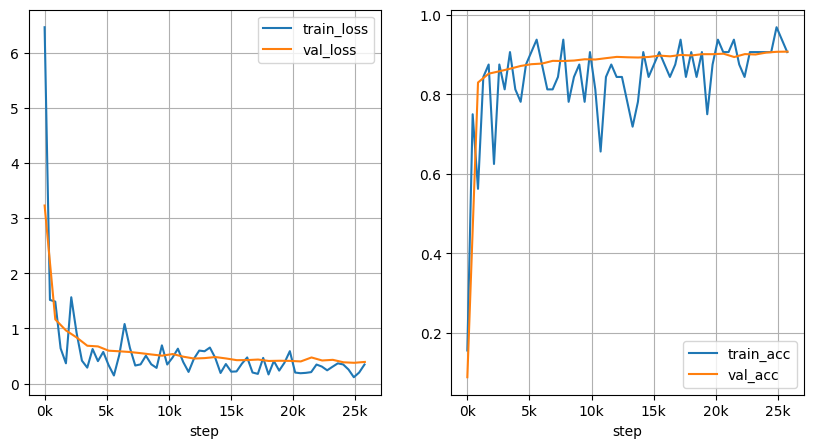

In [ ]:
# 注意：损失值不一定在 [0, 1] 范围内（与准确率不同），绘图时纵轴需适当缩放
sample_step=eval_step//2
# 定义绘制学习曲线的函数，将训练集和验证集的损失、准确率随训练步数的变化可视化
# 参数说明：
#   record_dict (dict)：包含训练和验证历史的字典，格式与 training() 返回值一致
#   sample_step (int) ：训练集数据降采样间隔，每隔 sample_step 步取一个点绘图（训练集数据量大）；默认 500
def plot_learning_curves(record_dict, sample_step=500):
    # 将训练历史列表转为 DataFrame，以 step 列为行索引，按 sample_step 间隔下采样（减少绘图点数）
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    # 将验证历史列表转为 DataFrame，以 step 为行索引（验证频率本来就低，无需再降采样）
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # 根据指标数量创建并排子图（如 loss 和 acc 共 2 个子图）
    fig_num = len(train_df.columns)  # 统计要绘制的指标数量（train_df 的列数）
    # plt.subplots 参数说明：
    #   nrows=1, ncols=fig_num ：1 行 fig_num 列的子图网格
    #   figsize=(宽, 高)        ：整体图形尺寸，每个子图宽 5 英寸，高 5 英寸
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):  # 遍历每个指标（如 'loss'、'acc'）
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")  # 绘制训练集指标折线
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")        # 绘制验证集指标折线
        axs[idx].grid()    # 开启网格线，便于读取数值
        axs[idx].legend()  # 显示图例（区分训练曲线和验证曲线）
        # 设置 x 轴刻度：从 0 到最大 step，每 5000 步一个刻度
        axs[idx].set_xticks(range(0, train_df.index[-1], 5000))
        # 将 x 轴刻度标签格式化为 "xk" 形式（如 5000 → "5k"），提升可读性
        # map(lambda, range) 对每个刻度值应用格式化函数
        axs[idx].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, train_df.index[-1], 5000)))
        axs[idx].set_xlabel("step")  # 设置 x 轴标签文字为 "step"

    plt.show()  # 渲染并显示所有子图

# 调用绘图函数，横坐标为训练步数（steps），每隔 500 步取一个训练集数据点绘图
plot_learning_curves(record, sample_step=sample_step)

## 五、评估

### 5.1 加载最优权重并在测试集上评估

In [ ]:
# 加载训练过程中保存的最优模型权重，并在测试集上进行最终评估

# 从磁盘加载最优检查点权重并填充到模型中
# torch.load 参数说明：
#   f             (str) ：检查点文件路径，best.ckpt 为 SaveCheckpointsCallback 保存的最优权重文件
#   weights_only  (bool)：True 表示只加载权重张量，不执行任意 Python 代码，避免安全风险（PyTorch 2.0+ 推荐）
#   map_location  (str) ："cpu" 表示将权重映射到 CPU，即使原来保存在 GPU 上也能正确加载
# model.load_state_dict：将加载的 state_dict（参数字典）填充到当前模型结构中
model.load_state_dict(torch.load(f"model_checkpoints/2_model/2_model_best.ckpt", weights_only=True, map_location="cpu"))

model.eval()  # 切换模型至评估模式（关闭 Dropout 等训练专用行为，保证推理结果确定性）

# 在测试集上完整评估模型性能，返回平均损失和准确率
loss, acc = evaluating(model, test_loader, loss_fct)

# 打印评估结果，保留 4 位小数便于精确对比
# loss：测试集平均交叉熵损失
# acc ：测试集分类准确率（0~1，越大越好）
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     0.4227
accuracy: 0.9072
